In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [2]:
data_dir = '/home/rmhihbp/my_ukb_thesis/data'
file_path = os.path.join(data_dir, 'split_A_explore.parquet')
df_explore = pd.read_parquet(file_path)
print(f'shape of the scaled dataframe: {df_explore.shape}')

shape of the scaled dataframe: (22943, 28)


In [3]:
target_col = 'def_CVD_AF_HF_AFTER'
drop_cols = ['eid', target_col]

X_raw = df_explore.drop(columns=[col for col in drop_cols if col in df_explore.columns])
Y = df_explore[target_col]

feature_names = X_raw.columns.tolist()
print(f'number of features: {len(feature_names)}')

number of features: 26


In [4]:
# Single imputation using IterativeImputer
imputer = IterativeImputer(max_iter=10, random_state=42)
X_imputed_array = imputer.fit_transform(X_raw)
X_imputed = pd.DataFrame(X_imputed_array, columns=feature_names, index=X_raw.index)

In [6]:
# standardization
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_imputed)
X_scaled = pd.DataFrame(X_scaled_array, columns=feature_names, index=X_raw.index)

In [7]:
# elastic net
elastic_net_model = LogisticRegression( 
    penalty='elasticnet', 
    solver='saga',        
    l1_ratio=0.5,         
    C=0.005,               
    class_weight='balanced', 
    max_iter=2000,        
    random_state=42,
    n_jobs=-1             
)

elastic_net_model.fit(X_scaled, Y) 

y_pred_prob = elastic_net_model.predict_proba(X_scaled)[:, 1]
auc_score = roc_auc_score(Y, y_pred_prob)

print(f'split A internal fit AUC score: {auc_score:.4f}')

split A internal fit AUC score: 0.7240


In [8]:
coefficients = elastic_net_model.coef_[0]

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})

feat_imp_df = feat_imp_df.sort_values(by='Abs_Coefficient', ascending=False).reset_index(drop=True)

retained_features = feat_imp_df[feat_imp_df['Abs_Coefficient'] > 1e-5]['Feature'].tolist()
zero_features = feat_imp_df[feat_imp_df['Abs_Coefficient'] <= 1e-5]['Feature'].tolist()

print(f'number of significant features: {len(retained_features)}')
print(f'number of non significant features: {len(zero_features)}')

if len(zero_features) > 0:
    print(f'non significant features: {zero_features}')

print(f"\nsignificant features:")
for idx, row in feat_imp_df.head(len(retained_features)).iterrows():
    print(f"{row['Feature']:>35} | coef: {row['Coefficient']:.4f}")

number of significant features: 19
number of non significant features: 7
non significant features: ['diet_total', 'device_pc', 'MobUse_5-8yr', 'MobUse_>8yr', 'ProcMeat_1wk', 'ProcMeat_5-6wk', 'ProcMeat_daily']

significant features:
               age_defined_baseline | coef: 0.6404
                        genetic_sex | coef: 0.3308
                                BMI | coef: 0.1902
                           smk_curr | coef: 0.1169
                           FH_cvd_m | coef: 0.0793
                         FH_cvd_sib | coef: 0.0741
                      mental_doctor | coef: 0.0602
                         uni_degree | coef: -0.0578
                           FH_cvd_f | coef: 0.0464
                           alc_curr | coef: -0.0452
                          PA_active | coef: -0.0421
                           alc_prev | coef: 0.0384
                      ProcMeat_<1wk | coef: -0.0211
                        MobUse_≤1yr | coef: 0.0139
                       MobUse_2-4yr | coef: 0.012

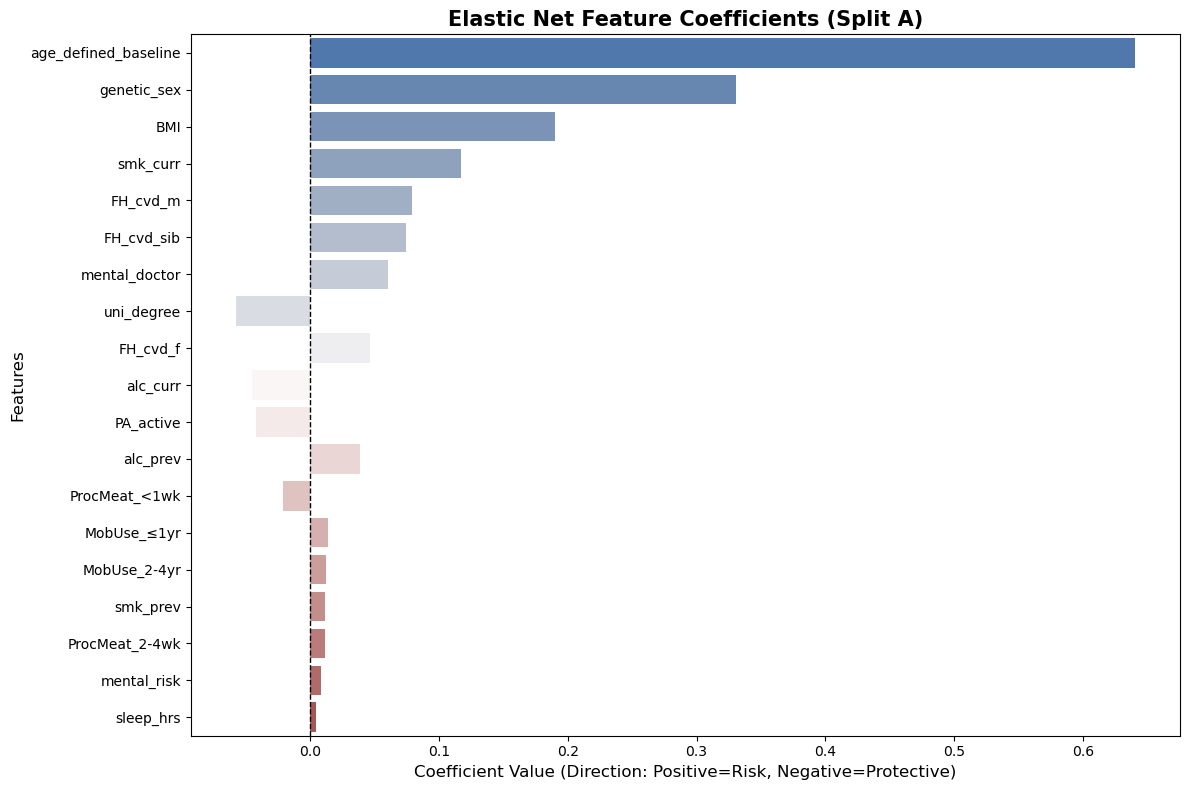

In [9]:
plt.figure(figsize=(12, 8))

sns.barplot(
    x='Coefficient', 
    y='Feature', 
    hue='Feature',
    data=feat_imp_df[feat_imp_df['Abs_Coefficient'] > 1e-5], 
    palette='vlag',
    legend=False
)
plt.title('Elastic Net Feature Coefficients (Split A)', fontsize=15, fontweight='bold')
plt.xlabel('Coefficient Value (Direction: Positive=Risk, Negative=Protective)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

In [10]:
print('\n======= Final significant features in split A =======')
final_features = ['age_defined_baseline', 'genetic_sex', 'BMI','uni_degree', 'FH_cvd_f', 'FH_cvd_m', 'FH_cvd_sib',
                'sleep_hrs','mental_doctor','smk_prev', 'smk_curr', 'alc_curr', 'PA_active']
print(final_features)


======= Final significant features in split A =======
['age_defined_baseline', 'genetic_sex', 'BMI', 'uni_degree', 'FH_cvd_f', 'FH_cvd_m', 'FH_cvd_sib', 'sleep_hrs', 'mental_doctor', 'smk_prev', 'smk_curr', 'alc_curr', 'PA_active']
